In [1]:
import pandas as pd
import matplotlib.pyplot as plt

C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv("dec-2025-individual-call-records.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14489 entries, 0 to 14488
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             14489 non-null  int64  
 1   Activity date         14489 non-null  str    
 2   Call direction        14344 non-null  str    
 3   Call duration         14387 non-null  str    
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  13435 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 1.3 MB


In [4]:
df

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,97386856029,2025-12-01 06:02,Inbound,00:00:00,NaN,NaN
1,97383202709,2025-12-01 07:15,Inbound,00:00:00,NaN,NaN
2,97383894616,2025-12-01 08:51,Inbound,00:00:00,NaN,NaN
3,97377466645,2025-12-01 09:01,Outbound,00:03:23,NaN,David Valdez
4,97385987671,2025-12-01 09:03,Outbound,00:00:07,NaN,Kunal Rajani
...,...,...,...,...,...,...
14484,100163907155,2025-12-31 18:03,Outbound,00:00:07,NaN,David Banister
14485,100161410935,2025-12-31 18:10,Outbound,00:00:02,NaN,Tyler Jury
14486,100123945791,2025-12-31 18:10,Outbound,00:00:02,NaN,Tyler Jury
14487,100158807052,2025-12-31 18:38,Outbound,00:00:07,NaN,Jerry Guadiana


In [5]:
df1=df.drop(columns=['hs_call_outcome', 'Record ID'])

In [6]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 14489 entries, 0 to 14488
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Activity date         14489 non-null  str  
 1   Call direction        14344 non-null  str  
 2   Call duration         14387 non-null  str  
 3   Activity assigned to  13435 non-null  str  
dtypes: str(4)
memory usage: 1.0 MB


In [7]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

# Call Count per day

In [9]:
df2 = df1.copy()

In [10]:
df2['date'] = df2['Activity date'].dt.date

In [11]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2025-12-01 06:02:00,Inbound,00:00:00,NaN,2025-12-01
1,2025-12-01 07:15:00,Inbound,00:00:00,NaN,2025-12-01
2,2025-12-01 08:51:00,Inbound,00:00:00,NaN,2025-12-01
3,2025-12-01 09:01:00,Outbound,00:03:23,David Valdez,2025-12-01
4,2025-12-01 09:03:00,Outbound,00:00:07,Kunal Rajani,2025-12-01


In [12]:
daily_calls=(
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [13]:
daily_calls.head()

,date,call_count
0,2025-12-01,827
1,2025-12-02,771
2,2025-12-03,833
3,2025-12-04,813
4,2025-12-05,824


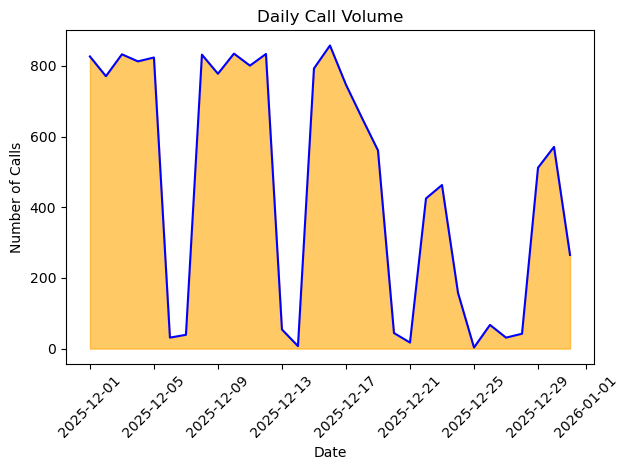

In [14]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'], color='blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color='orange', alpha=0.6)

plt.title("Daily Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [16]:
df1['day'] = df1['Activity date'].dt.day_name()

In [17]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2025-12-01 06:02:00,Inbound,00:00:00,NaN,Monday
1,2025-12-01 07:15:00,Inbound,00:00:00,NaN,Monday
2,2025-12-01 08:51:00,Inbound,00:00:00,NaN,Monday
3,2025-12-01 09:01:00,Outbound,00:03:23,David Valdez,Monday
4,2025-12-01 09:03:00,Outbound,00:00:07,Kunal Rajani,Monday


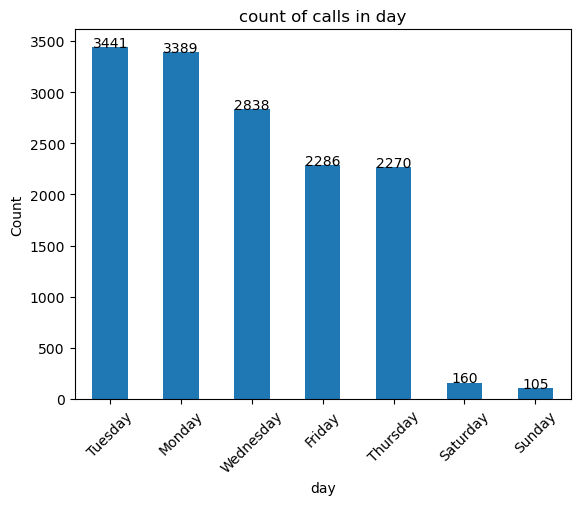

In [18]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax = day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i,v+1, str(v), ha= "center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

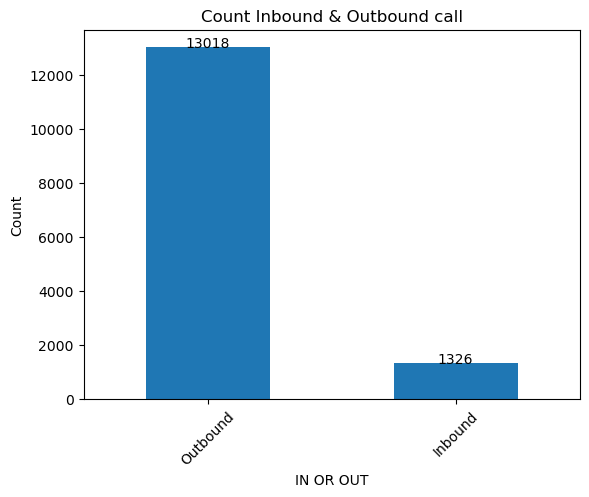

In [20]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i,v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel('IN OR OUT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [22]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

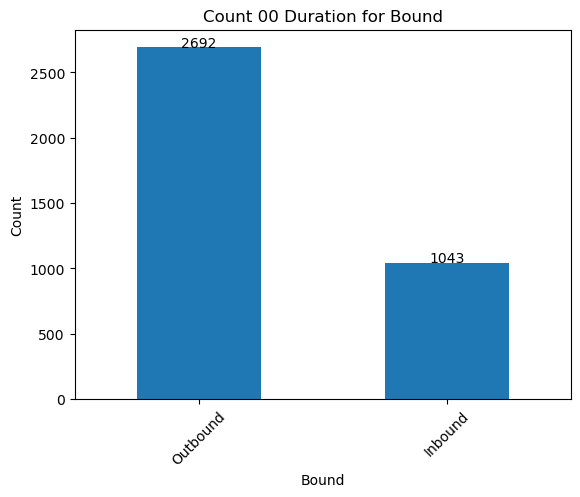

In [23]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction

In [25]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
977,2025-12-02 12:00:00,Outbound,NaN,Cameron Dudley,Tuesday
1236,2025-12-02 16:59:00,Outbound,NaN,Oliver Martin,Tuesday
1237,2025-12-02 17:00:00,Outbound,NaN,Cameron Dudley,Tuesday
1238,2025-12-02 17:00:00,Outbound,NaN,Oliver Martin,Tuesday
1327,2025-12-02 18:30:00,Outbound,NaN,Oliver Martin,Tuesday


In [26]:
df4 = df1.copy()

In [27]:
df4.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2025-12-01 06:02:00,Inbound,00:00:00,NaN,Monday
1,2025-12-01 07:15:00,Inbound,00:00:00,NaN,Monday
2,2025-12-01 08:51:00,Inbound,00:00:00,NaN,Monday
3,2025-12-01 09:01:00,Outbound,00:03:23,David Valdez,Monday
4,2025-12-01 09:03:00,Outbound,00:00:07,Kunal Rajani,Monday


In [28]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [29]:
(df4['Call duration'] == 0).sum()

3735

In [30]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 14489 entries, 0 to 14488
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         14489 non-null  datetime64[us]
 1   Call direction        14344 non-null  str           
 2   Call duration         14387 non-null  float64       
 3   Activity assigned to  13435 non-null  str           
 4   day                   14489 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 938.9 KB


In [31]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [32]:
df4 = df4.dropna(subset = ['Call direction'])

In [33]:
(df4['Call duration'] == 0).sum()

3740

In [34]:
df4.info()

<class 'pandas.DataFrame'>
Index: 14344 entries, 0 to 14488
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         14344 non-null  datetime64[us]
 1   Call direction        14344 non-null  str           
 2   Call duration         14344 non-null  float64       
 3   Activity assigned to  13302 non-null  str           
 4   day                   14344 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 1.0 MB


# Working Call Assigner

In [36]:
df1['Activity assigned to'].nunique()

35

In [37]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[                     nan,           'David Valdez',           'Kunal Rajani',
          'Oliver Martin',          'Marvin Laguna',           'Robin Stoehr',
          'Keith Antonio',           'Cameron Byrd',            'Zach Drissi',
         'Jerry Guadiana',              'Juan Calo',         'Andrew Stewart',
         'Salvador Pardo',         'Isaiah Trousil',          'Sam Steindorf',
            'Tyler Smith',          'Garrett Evans',        'Georgi Stanchev',
         'Nick Rothacher',             'Tyler Jury',           'Jerome Joyce',
        'Cameron Partlow',        'Alejandra Hanks',            'Jinky Rance',
                 'Abhi C',       'Chrystel Manabat',         'David Banister',
      'Brittany Digiulio', 'Jannica Nikka Antipuna',         'Cameron Dudley',
         'Tommy Canfield',        'Adonis Baybayan',       'Shawn Richardson',
           'Bill Goodwin',         'Boston Hoppman',             'Matt Jones']
Length: 36, dtype: str

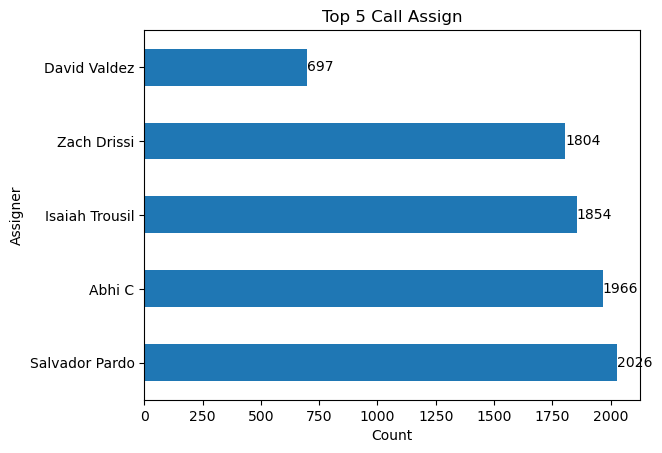

In [38]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [40]:
df4['Call duration'].max()

97.55

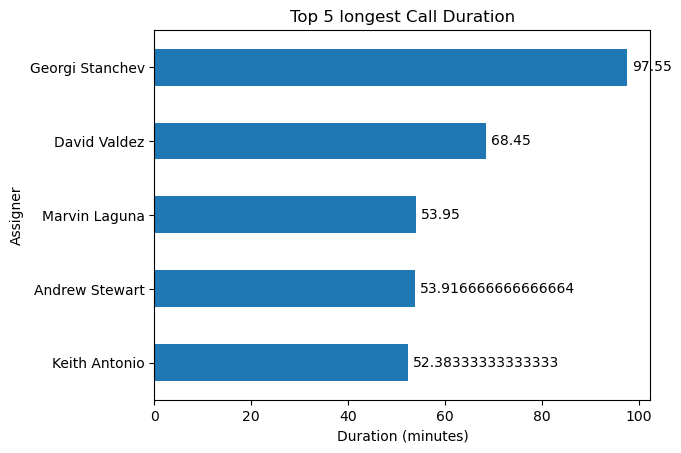

In [41]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Weekdays Call Volume

In [43]:
df3=df1.copy()

In [44]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [45]:
df3['day'].unique()

<ArrowStringArray>
['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Length: 5, dtype: str

In [46]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

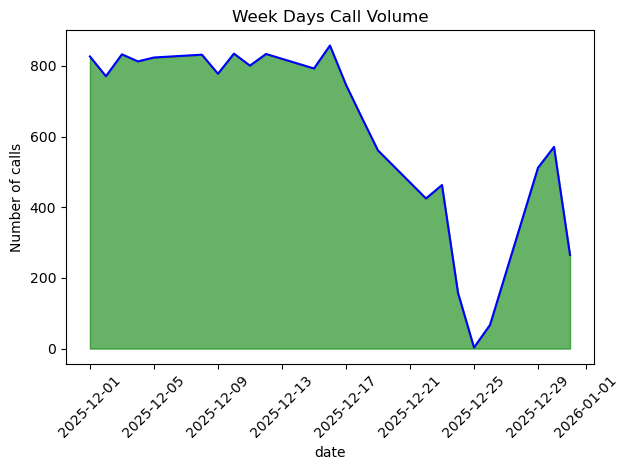

In [47]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [49]:
df5=df4.copy()

In [50]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [51]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
4068,2025-12-06 09:27:00,Inbound,0.0,NaN,Saturday
4069,2025-12-06 10:56:00,Inbound,0.0,NaN,Saturday
4070,2025-12-06 11:35:00,Inbound,0.0,NaN,Saturday
4071,2025-12-06 11:44:00,Inbound,0.0,NaN,Saturday
4072,2025-12-06 12:51:00,Inbound,0.0,NaN,Saturday


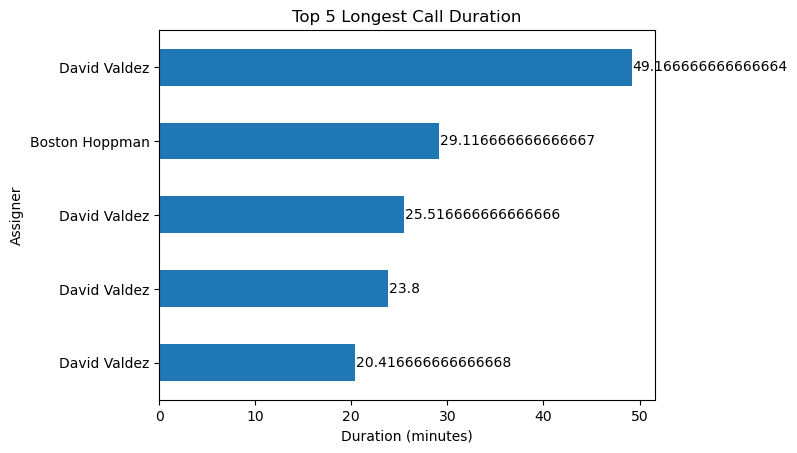

In [52]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top5 Weekend Call Assigner

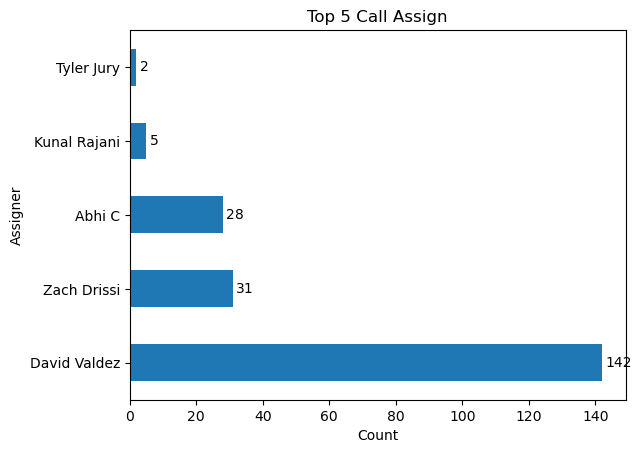

In [54]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Average Call Duration

In [56]:
df4["Call duration"].mean()

2.0140569808514592

In [57]:
df4["Call duration"].median()

0.08333333333333333

# Without Call Assigner Calls

In [59]:
df6 = df3.copy()

In [60]:
df6['month'] = df6['Activity date'].dt.month_name()

In [61]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

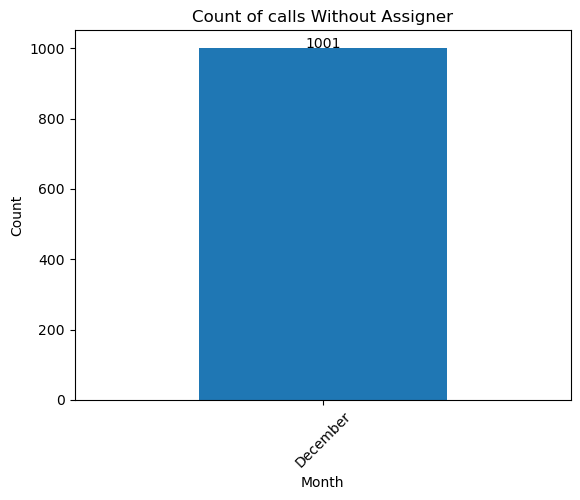

In [62]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top5 peak Call date

In [64]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2025-12-01 06:02:00,Inbound,00:00:00,NaN,2025-12-01
1,2025-12-01 07:15:00,Inbound,00:00:00,NaN,2025-12-01
2,2025-12-01 08:51:00,Inbound,00:00:00,NaN,2025-12-01
3,2025-12-01 09:01:00,Outbound,00:03:23,David Valdez,2025-12-01
4,2025-12-01 09:03:00,Outbound,00:00:07,Kunal Rajani,2025-12-01


In [65]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [66]:
top5 = daily_calls.sort_values(ascending=False).head(5)

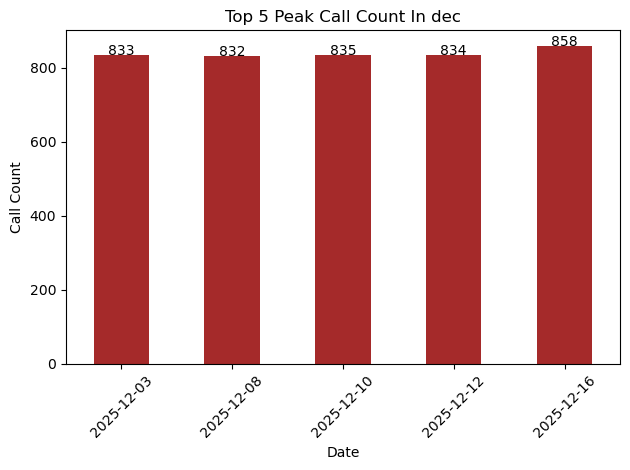

In [67]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In dec")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()